Install and Import Libraries

In [ ]:
# Install required libraries
!pip install -q mahotas
!pip install -q albumentations

# Import required dependencies
import os
import cv2
import mahotas
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from albumentations import Compose, HorizontalFlip, RandomBrightnessContrast, Rotate
from sklearn.decomposition import PCA
from collections import Counter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 39.6 MB/s eta 0:00:00


Install Kaggle and Download Dataset

In [ ]:
# Install Kaggle API
!pip install -q kaggle

# Set up Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset from Kaggle
!kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset

# Unzip the dataset
!unzip -q corn-or-maize-leaf-disease-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset
License(s): copyright-authors
 91% 147M/161M [00:00<00:00, 278MB/s]
100% 161M/161M [00:00<00:00, 291MB/s]


Initialise the Random Seed

In [ ]:
# Set global random seed
SEED = 42
random.seed(42)
np.random.seed(42)

Set Path

In [ ]:
# Check extracted folder
!ls

corn-or-maize-leaf-disease-dataset.zip	data  kaggle.json  sample_data


In [ ]:
# Define image directory path
data_dir = "/content/data"

# Check class folders
classes = os.listdir(data_dir)
print("Classes:", classes)

Classes: ['Common_Rust', 'Blight', 'Healthy', 'Gray_Leaf_Spot']


Image Preprocessing

In [ ]:
# Image size (resize all to same size)
img_size = 224

# Define augmentation sequence
augmenter = Compose([
    HorizontalFlip(p=0.5),
    Rotate(limit=20, p=0.5),
    RandomBrightnessContrast(p=0.5)
])

# Function to extract features
def extract_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_norm = gray / 255.0
    return gray_norm.flatten()

# Load and extract original data
image_paths = []
labels = []

for label in classes:
    class_path = os.path.join(data_dir, label)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        image_paths.append(img_path)
        labels.append(label)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Labels:", labels.shape)

Labels: (4188,)


Original Class Distribution

In [ ]:
print("Original Class Counts:", Counter(labels))

Original Class Counts: Counter({np.str_('Common_Rust'): 1306, np.str_('Healthy'): 1162, np.str_('Blight'): 1146, np.str_('Gray_Leaf_Spot'): 574})


Train-Test Split

In [ ]:
# Split off Train-Test set (80-20%)
X_train_paths, X_test_paths, y_train, y_test = train_test_split(image_paths, labels, test_size=0.2, stratify=labels, random_state=SEED)

print("Train size:", len(y_train))
print("Test size:", len(y_test))

Train size: 3350
Test size: 838


Data Augmentation

In [ ]:
# Augmentation only on the training set
train_features, train_labels = [], []

for img_path, label in zip(X_train_paths, y_train):
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, (img_size, img_size))
        # Apply augmentation
        augmented = augmenter(image=img)
        img_aug = augmented["image"]
        # Extract features
        features = extract_features(img_aug)
        train_features.append(features)
        train_labels.append(label)

# Test set (no augmentation)
test_features, test_labels = [], []

for img_path, label in zip(X_test_paths, y_test):
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, (img_size, img_size))
        features = extract_features(img)
        test_features.append(features)
        test_labels.append(label)

X_train = np.array(train_features)
X_test = np.array(test_features)
y_train = np.array(train_labels)
y_test = np.array(test_labels)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3350, 50176)
Test shape: (838, 50176)


Encode Labels

In [ ]:
# Encoding
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

Scaling Features

In [ ]:
# Data Standardization
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

PCA

In [ ]:
# Apply PCA
pca = PCA(n_components=0.60, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

print("After PCA:", X_train_pca.shape, X_test_pca.shape)

After PCA: (3350, 5) (838, 5)


Train Random Forest Model

In [ ]:
# --- RF WITH GRID SEARCH ---

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'bootstrap': [True, False]
}

# Initialize and fit GridSearchCV
rf = RandomForestClassifier(random_state=SEED)
rf_model = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
rf_model.fit(X_train_pca, y_train_enc)

# Best parameters and estimator
print("Best Parameters:\n", rf_model.best_params_)
print(f"Best Cross-Validation Accuracy: {rf_model.best_score_ * 100:.2f}%")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
 {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy: 67.91%


Evaluate Test Set

In [ ]:
# Predict on Test Set
y_pred = rf_model.predict(X_test_pca)
y_prob = rf_model.predict_proba(X_test_pca)

Evaluate Model — Accuracy, Precision, Recall, F1, Confusion Matrix and Roc Auc Score

In [ ]:
# Classification Report
print("Classification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Classification Report:

                precision    recall  f1-score   support

        Blight       0.55      0.93      0.69       229
   Common_Rust       0.97      0.86      0.91       261
Gray_Leaf_Spot       0.33      0.02      0.03       115
       Healthy       0.82      0.75      0.78       233

      accuracy                           0.73       838
     macro avg       0.67      0.64      0.61       838
  weighted avg       0.73      0.73      0.70       838



In [ ]:
# Accuracy
accuracy = accuracy_score(y_test_enc, y_pred) * 100
print(f"Accuracy: {accuracy:.2f}%")

# Precision (Weighted Avg)
precision = precision_score(y_test_enc, y_pred, average='weighted') * 100
print(f"Precision (Weighted Avg): {precision:.2f}%")

# Recall (Weighted Avg)
recall = recall_score(y_test_enc, y_pred, average='weighted') * 100
print(f"Recall (Weighted Avg): {recall:.2f}%")

# F1 Score (Weighted Avg)
f1 = f1_score(y_test_enc, y_pred, average='weighted') * 100
print(f"F1 Score (Weighted Avg): {f1:.2f}%")

# ROC AUC (Weighted Avg)
try:
    auc_score = roc_auc_score(y_test_enc, y_prob, multi_class='ovr', average='weighted') * 100
    print(f"ROC AUC Score (Weighted Avg): {auc_score:.2f}%")
except Exception as e:
    print("ROC AUC not available:", e)

Accuracy: 73.39%
Precision (Weighted Avg): 72.51%
Recall (Weighted Avg): 73.39%
F1 Score (Weighted Avg): 69.56%
ROC AUC Score (Weighted Avg): 90.94%


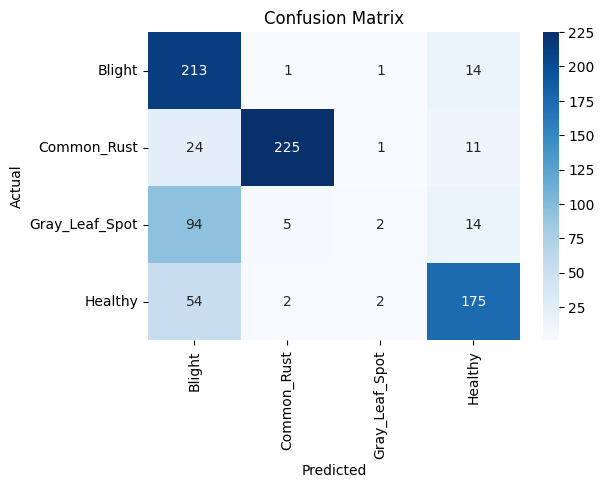

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Overfitting/Underfitting Check

In [ ]:
# Accuracy scores
train_acc = accuracy_score(y_train_enc, rf_model.predict(X_train_pca)) * 100
test_acc = accuracy_score(y_test_enc, y_pred) * 100

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

# Interpretation
if train_acc - test_acc > 10:
    print("Possible Overfitting: Model performs much better on training data.")
elif test_acc - train_acc > 10:
    print("Possible Underfitting: Model performs better on test data.")
elif train_acc < 60 and test_acc < 60:
    print("Underfitting: Model is not learning patterns well.")
else:
    print("Model is generalizing well.")

Training Accuracy: 78.12%
Test Accuracy: 73.39%
Model is generalizing well.
